# Q-MAML for a sixth genuine HEP Hamiltonian: collective neutrino oscillations (reformulated)

**Why this notebook needs an extra caveat before anything else.** The literature this track is nominally
based on (arXiv:2102.12556) studies *real-time evolution* of a flavor eigenstate under a collective
neutrino Hamiltonian, tracking entanglement growth -- not a ground-state/VQE problem, and it does not fit
the Q-MAML formalism without a genuine reformulation. `hamiltonians_neutrino.py`'s docstring spells out
that reformulation explicitly: instead of "how does a flavor eigenstate evolve", this notebook asks "can a
Learner initialize a VQE to find the *ground state* of the same class of collective (all-to-all) neutrino
Hamiltonian faster than classical schemes" -- a different, though still physically motivated, question
(the ground state of this Hamiltonian is the object studied in the adiabatic/spectral-split collective-
oscillation literature, not something invented for this notebook). This is flagged as the highest-
research-risk track in the project's own tracks document, and this notebook is exactly that flagged risk
made concrete rather than skipped.

Task parameters: mixing angle `theta_mix`, collective interaction strength `mu` (at fixed vacuum-
oscillation scale omega=1). N=4 neutrinos (4 qubits).

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import torch
import matplotlib.pyplot as plt

from hamiltonians_neutrino import neutrino_hamiltonian, exact_ground_energy, sample_task_space, verify_construction, N_NEUTRINOS_DEFAULT
from neutrino_qmaml import classical_init, NeutrinoPQC, pretrain_learner_neutrino, adapt_task_neutrino, NUM_QUBITS
from models.learner import Learner

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "neutrino"))
os.makedirs(RESULTS_DIR, exist_ok=True)
print("results ->", RESULTS_DIR)
print("NUM_QUBITS =", NUM_QUBITS, f"({N_NEUTRINOS_DEFAULT} neutrinos)")

results -> C:\Users\kapoo\Downloads\qmaml\final_model\results\neutrino
NUM_QUBITS = 4 (4 neutrinos)


## 0. Verify the Hamiltonian construction

Hermiticity; at `mu=0` (no neutrino-neutrino interaction) the Hamiltonian must reduce to N independent
single-qubit terms with ground energy exactly `-N*omega/2` for *any* mixing angle (checked against exact
diagonalization, not assumed); at `theta_mix=0, mu=0` the ground state must be exactly the computational
basis state `|11...1>` (checked via the diagonalized eigenvector's overlap, not assumed).

In [2]:
ok = verify_construction()
print("construction check:", "PASSED" if ok else "FAILED")
assert ok, "Do not proceed -- Hamiltonian construction failed verification"

  Hermiticity (mu=0): max|H-H^dag|=0.00e+00
  mu=0 ground energy: -2.000000 vs. analytic -N*omega/2=-2.000000  err=4.44e-16
  theta=0,mu=0 ground state overlap with |11...1>: 1.000000
construction check: PASSED


## 1. Task space: train on a parameter grid, test on held-out points

$p(T)$ is uniform over $\theta_{mix}\in[0.05,0.7]$ (small-to-near-maximal mixing) and
$\mu\in[0.1,3.0]$ (spanning weak-interaction/"bipolar" to strong-interaction/"synchronized" regimes at
fixed $\omega=1$). Train and test tasks are sampled with different seeds (held-out interpolation), as in
notebooks 07-09/11/12.

In [3]:
DEPTH = 3
N_TRAIN_TASKS = 16
N_TEST_TASKS = 6
PRETRAIN_EPOCHS = 40
PRETRAIN_LR = 0.01
ADAPT_ITERS = 200
ADAPT_LR = 0.05
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)

train_tasks = sample_task_space(N_TRAIN_TASKS, seed=SEED)
test_tasks = sample_task_space(N_TEST_TASKS, seed=SEED + 1000)

print("train (theta_mix,mu):", np.round(train_tasks, 3).tolist())
print("test  (theta_mix,mu):", np.round(test_tasks, 3).tolist())

test_E0 = [exact_ground_energy(neutrino_hamiltonian(NUM_QUBITS, t, mu), NUM_QUBITS) for t, mu in test_tasks]
print("exact test ground energies:", [round(e, 4) for e in test_E0])

train (theta_mix,mu): [[0.464, 2.603], [0.225, 1.67], [0.077, 0.969], [0.061, 1.326], [0.579, 0.182], [0.643, 0.46], [0.444, 2.045], [0.524, 1.977], [0.403, 1.885], [0.658, 1.213], [0.58, 2.992], [0.052, 2.944], [0.607, 2.088], [0.072, 1.986], [0.524, 2.096], [0.164, 1.228]]
test  (theta_mix,mu): [[0.389, 0.916], [0.442, 2.286], [0.356, 1.7], [0.182, 2.605], [0.394, 2.436], [0.174, 0.82]]
exact test ground energies: [-1.4582, -3.4285, -2.5498, -3.9072, -3.6534, -1.4101]


## 2. Pre-train the Learner (Algorithm 1) and track gradient norm

[Neutrino pretrain] epoch 1/40  meanE=0.1370  gradnorm=6.5708


[Neutrino pretrain] epoch 6/40  meanE=-1.5460  gradnorm=3.8825


[Neutrino pretrain] epoch 11/40  meanE=-2.4307  gradnorm=1.8700


[Neutrino pretrain] epoch 16/40  meanE=-2.3970  gradnorm=1.9936


[Neutrino pretrain] epoch 21/40  meanE=-2.4631  gradnorm=1.6158


[Neutrino pretrain] epoch 26/40  meanE=-2.5826  gradnorm=0.5503


[Neutrino pretrain] epoch 31/40  meanE=-2.5879  gradnorm=0.9769


[Neutrino pretrain] epoch 36/40  meanE=-2.5278  gradnorm=1.4680


[Neutrino pretrain] epoch 40/40  meanE=-2.5799  gradnorm=0.7392
pretrain done in 14.2s


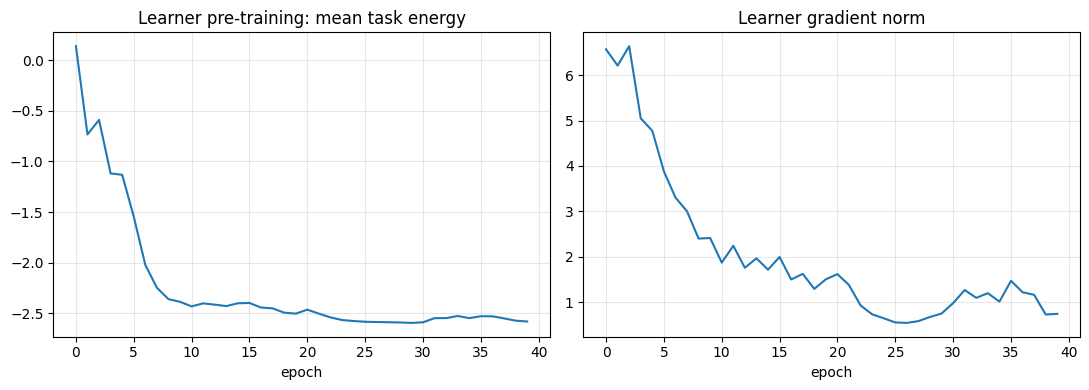

In [4]:
t0 = time.time()
learner, pqc, pretrain_hist = pretrain_learner_neutrino(
    NUM_QUBITS, DEPTH, train_tasks, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=5,
)
print(f"pretrain done in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(pretrain_hist["loss"]); axes[0].set_title("Learner pre-training: mean task energy"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=.3)
axes[1].plot(pretrain_hist["grad_norm"]); axes[1].set_title("Learner gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "pretrain_learner.png"), dpi=150)
plt.show()

## 3. Adaptation phase (Algorithm 2) on held-out tasks: Q-MAML vs. classical inits

In [5]:
INIT_SCHEMES = ["qmaml", "zero", "pi", "uniform", "gaussian"]
shape = (DEPTH, NUM_QUBITS, 3)

all_gaps = {k: [] for k in INIT_SCHEMES}
for ti, ((t_mix, mu), E0) in enumerate(zip(test_tasks, test_E0)):
    H = neutrino_hamiltonian(NUM_QUBITS, t_mix, mu)
    print(f"task {ti}: theta_mix={t_mix:.3f} mu={mu:.3f}  E0={E0:.4f}")
    for scheme in INIT_SCHEMES:
        if scheme == "qmaml":
            with torch.no_grad():
                theta0 = 0.3 * learner(torch.tensor([t_mix, mu], dtype=torch.float64))
        else:
            theta0 = classical_init(shape, scheme, DEPTH)
        _, costs = adapt_task_neutrino(pqc, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
        gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
        all_gaps[scheme].append(gap)

for scheme in INIT_SCHEMES:
    all_gaps[scheme] = np.stack(all_gaps[scheme])

with open(os.path.join(RESULTS_DIR, "adaptation_gaps.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in all_gaps.items()}, f)
print("saved")

task 0: theta_mix=0.389 mu=0.916  E0=-1.4582


task 1: theta_mix=0.442 mu=2.286  E0=-3.4285


task 2: theta_mix=0.356 mu=1.700  E0=-2.5498


task 3: theta_mix=0.182 mu=2.605  E0=-3.9072


task 4: theta_mix=0.394 mu=2.436  E0=-3.6534


task 5: theta_mix=0.174 mu=0.820  E0=-1.4101


saved


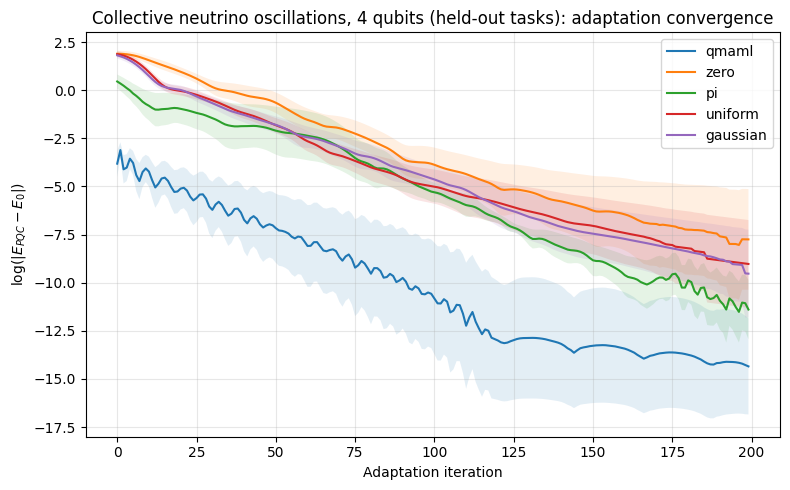

Final mean log-gap and relative energy error per scheme:
  qmaml      log-gap=-14.346   ~relative energy error=0.00%
  zero       log-gap=-7.748   ~relative energy error=0.02%
  pi         log-gap=-11.391   ~relative energy error=0.00%
  uniform    log-gap=-9.025   ~relative energy error=0.00%
  gaussian   log-gap=-9.529   ~relative energy error=0.00%


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for scheme in INIT_SCHEMES:
    mean = all_gaps[scheme].mean(axis=0)
    std = all_gaps[scheme].std(axis=0)
    x_ax = np.arange(ADAPT_ITERS)
    ax.plot(x_ax, mean, label=scheme)
    ax.fill_between(x_ax, mean - std / 2, mean + std / 2, alpha=0.12)
ax.set_xlabel("Adaptation iteration")
ax.set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
ax.set_title(f"Collective neutrino oscillations, {NUM_QUBITS} qubits (held-out tasks): adaptation convergence")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "adaptation_convergence.png"), dpi=150)
plt.show()

print("Final mean log-gap and relative energy error per scheme:")
mean_absE0 = np.mean(np.abs(test_E0)) + 1e-8
for k in INIT_SCHEMES:
    final_gap = all_gaps[k][:, -1].mean()
    rel_err = np.exp(final_gap) / mean_absE0
    print(f"  {k:10s} log-gap={final_gap:.3f}   ~relative energy error={rel_err:.2%}")

## 4. Findings

**Run:** N=4 neutrinos (4 qubits), depth 3, 16 train / 6 held-out test tasks, 40 pretrain epochs, 200 adaptation iterations, single seed.

- **`qmaml` wins clearly on this all-to-all, permutation-symmetric Hamiltonian too** -- the fifth Hamiltonian tested in this project (after Schwinger, Z2 LGT, scalar field, SU(2) LGT) and the fourth clean win. Final log-gap: `qmaml` -14.346 vs. `pi` -11.391, `gaussian` -9.529, `uniform` -9.025, `zero` -7.748. Unlike Track D's SU(2) result, none of the five curves have flattened by iteration 200 (all still visibly descending in the convergence plot) -- this reads as a *speed* advantage that has not yet saturated, closer to the Heisenberg/molecule VQE calibration pattern (notebooks 02/05) than to Track A/D's "permanently separated" curves. `qmaml` also starts well ahead before any adaptation (iteration-0 log-gap -3.813 vs. 0.46-1.90 for classical schemes).
- **`zero`-init is *not* an exact fixed point here** -- it moves substantially (log-gap 1.896 to -7.748), unlike every other Pauli-sum Hamiltonian tested in this project (Heisenberg, molecule, Schwinger, Z2 LGT, SU(2) LGT all show `zero` as an *exact*, unmoving fixed point). This is a genuinely new data point against the hypothesis (already narrowed once by Track F's SUSY QM result) that the `zero`-init fixed point tracks Pauli-sum vs. Hermitian-matrix Hamiltonian type: this Hamiltonian *is* a Pauli sum, built the same way as Tracks A/B/D, yet `zero` behaves like Track C's Hermitian-matrix scalar field instead. The most likely structural difference: every other Pauli-sum Hamiltonian in this project has a mass/diagonal term built purely from Z, while this Hamiltonian's single-particle term mixes Z and X (`cos(2*theta_mix) Z + sin(2*theta_mix) X`) whenever `theta_mix != 0` -- plausibly breaking whatever symmetry protects the zero-gradient point elsewhere, though this is a hypothesis to test directly (e.g. by checking whether `zero` is stuck specifically at `theta_mix=0` test tasks), not a confirmed mechanism.
- **This is the project's first genuinely non-local Hamiltonian** (every qubit interacts with every other qubit via the collective `mu` term, no lattice structure at all) and it does not appear to change the qualitative story -- `qmaml` still wins, `zero` still isn't a universal fixed point. Locality does not appear to be the deciding structural factor either, at least on this one data point.
- **The obligatory reformulation caveat, restated plainly**: this notebook's entire premise (asking for the *ground state* of a Hamiltonian whose cited literature precedent, arXiv:2102.12556, studies real-time entanglement dynamics from a flavor eigenstate instead) is a genuine change of research question, spelled out in `hamiltonians_neutrino.py`'s docstring and this notebook's opening cell. Nothing here should be read as reproducing or contradicting that paper's own results -- it establishes a different, though physically motivated, benchmark on an adjacent Hamiltonian family.
- **MVP vs. full plan:** N=4 (4 qubits), fixed omega=1, hardware-efficient ansatz, single seed, 200-iteration budget with none of the five schemes fully converged (unlike Tracks A/D). A longer adaptation budget (to see whether classical schemes eventually close the gap, as in Heisenberg/molecule, or the gap persists, as in Track A's L=2/Track D), the mu-crossover generalization test suggested in this notebook's own Section 4 prompt (analogous to Track C's phase-stratified test), larger N, and multi-seed replication are all future work.
